In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/titanic_data.csv")

In [7]:
# pandas crosstab

pd.crosstab(
    index = df.Sex,
    columns= df.Survived,
    margins= True,
    margins_name= "Total",
    colnames=["Rate of Survival"],
    rownames=["Gender"],
    
    # aggfunc = "mean",
    # values=df.Fare
)

Rate of Survival,0,1,Total
Gender,,,
female,81,233,314
male,468,109,577
Total,549,342,891


In [9]:
pd.crosstab(
    df.Sex,
    [df.Survived, df.Pclass],
    margins= False
)

Survived   0            1        
Pclass     1   2    3   1   2   3
Sex                              
female     3   6   72  91  70  72
male      77  91  300  45  17  47

In [10]:
# Get unique Values
df.Embarked.unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [11]:
df.Embarked.nunique(dropna= False)

4

In [12]:
# sum() , prod(), cumsum(), var(), std(),  mean(), quantile()
df.Age.quantile(q = 0.75)

np.float64(38.0)

In [13]:
df.Age.var()

np.float64(211.01912474630802)

In [14]:
df.Embarked.mode()

0    S
Name: Embarked, dtype: str

### 0 -> column wise -> vertical
### 1 -> row wise -> horizontal

In [15]:
df.isna().sum(axis = 0)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
# GroupBy

sample_df = df[["Sex","Fare","Age","Survived", "Embarked"]]
sample_df.head()

,Sex,Fare,Age,Survived,Embarked
0,male,7.2500,22.0,0,S
1,female,71.2833,38.0,1,C
2,female,7.9250,26.0,1,S
3,female,53.1000,35.0,1,S
4,male,8.0500,35.0,0,S


In [18]:
group_by_gender = sample_df.groupby(by="Sex")
group_by_gender

In [19]:
group_by_gender.mean(numeric_only=True)

,Fare,Age,Survived
Sex,,,
female,44.479818,27.915709,0.742038
male,25.523893,30.726645,0.188908


In [20]:
group_by_gender.value_counts(["Survived"])

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [21]:
group_by_two = df.groupby(by = ["Embarked", "Survived"])

In [22]:
group_by_two.count()

PassengerId  Pclass  Name  Sex  Age  SibSp  Parch  Ticket  \
Embarked Survived                                                              
C        0                  75      75    75   75   51     75     75      75   
         1                  93      93    93   93   79     93     93      93   
Q        0                  47      47    47   47   20     47     47      47   
         1                  30      30    30   30    8     30     30      30   
S        0                 427     427   427  427  353    427    427     427   
         1                 217     217   217  217  201    217    217     217   

                   Fare  Cabin  
Embarked Survived               
C        0           75     17  
         1           93     52  
Q        0           47      2  
         1           30      2  
S        0          427     49  
         1          217     80

## Correlation and Covariance

In [23]:
df[["Age", "Fare"]].cov()

,Age,Fare
Age,211.019125,73.849030
Fare,73.849030,2469.436846


In [24]:
df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


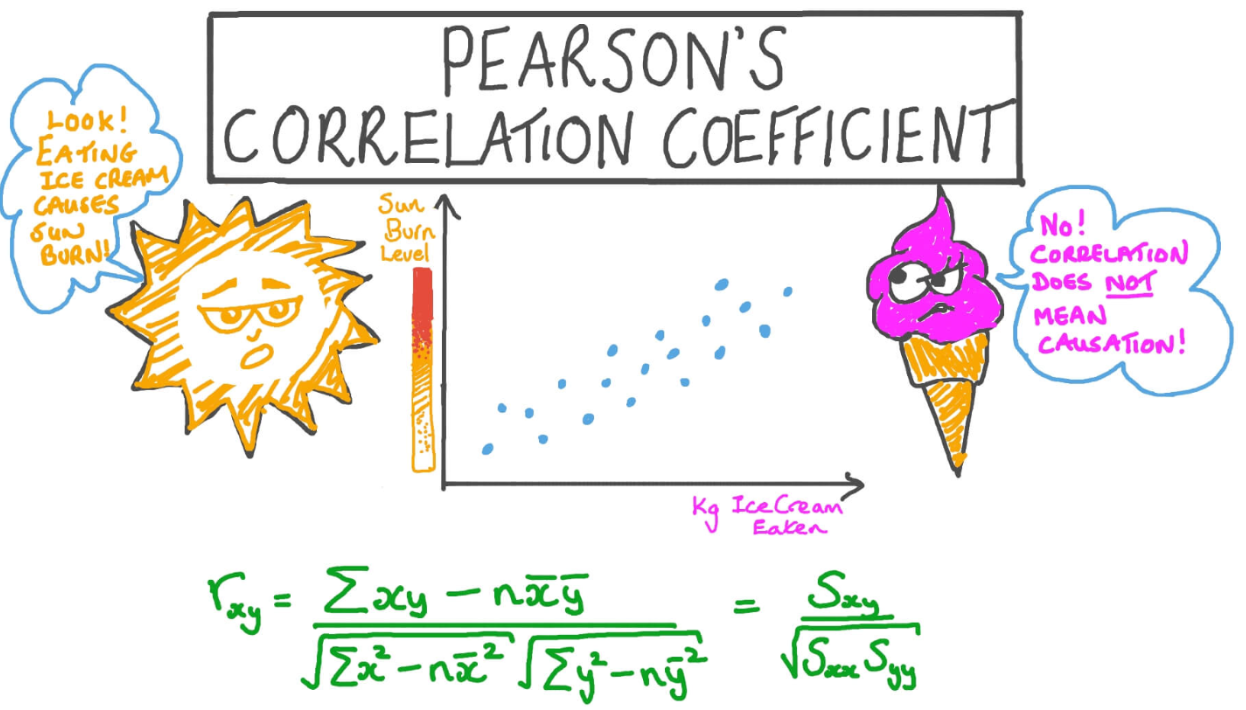

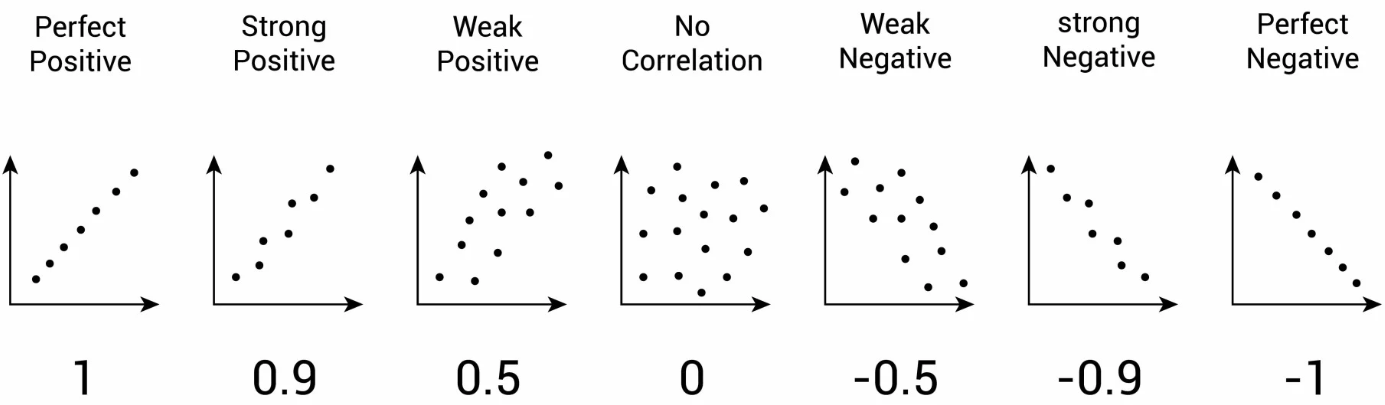

In [25]:
df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


In [26]:
df["Age"].corr(df["Fare"]) 

np.float64(0.09606669176903891)

In [27]:
# sample
sampled_df = df.sample(n = 300, random_state=999)

In [28]:
sampled_df.mean(numeric_only=True)

PassengerId    451.633333
Survived         0.366667
Pclass           2.353333
Age             29.880250
SibSp            0.530000
Parch            0.380000
Fare            31.413222
dtype: float64

In [29]:
sampled_df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.00000,0.03441
Fare,0.03441,1.00000
